# Re-Deriving the Branching Ratio 
...of eta -> mu+ mu- gamma, using the eta transition form factor from 1608.07898 (NA60, 2016), compared against the 1980 measurement.


**Author**: Michael Peters  

### Define constants and data

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import scipy.integrate as integrate
import matplotlib.pyplot as plt
from tabulate import tabulate
import math

from plot_style import COLORS, style_axes, apply_font
apply_font()

# Constants
ALPHA = 1. / 137. # m_Z mass scale
M_ETA = 0.547862  # from pdg
M_MU = .1056583745  # from pdg
BR_ETA2GG =.3936  # from pdg
prefactor = (2 * ALPHA) / (3 * np.pi) * BR_ETA2GG

# BESIII/PDG normalization-channel branching ratio: BR(eta -> mu+ mu- gamma) =
# (2.98 +/- 0.13)e-4, the PDG average now dominated by the 2025 BESIII
# measurement (arXiv:2506.08576).
BR0, DBR0 = 2.98e-4, 0.13e-4

In [2]:
# NOTE: this paper's Fig. 3 plots F^2 vs the dimuon MASS m_mumu (GeV/c^2), unlike
# the 1980 paper's Fig. 2, which plots vs mass-SQUARED. Squaring here converts the
# digitized x-axis to m^2_mumu (GeV^2/c^4) = q^2, which is what F(), F2(), fit(),
# and integrate() all expect as `x` below.
x_mass = np.array([0.21, 0.23, 0.25, 0.27, 0.29, 0.31, 0.33, 0.35, 0.37,
                    0.39, 0.41, 0.43, 0.45, 0.47])  # dimuon mass, GeV/c^2
x = x_mass ** 2  # q^2 = m^2_mumu, GeV^2/c^4
y = np.array([1.208, 1.250, 1.264, 1.367, 1.423, 1.522, 1.565, 1.677,
              1.796, 1.978, 2.105, 2.42, 2.77, 3.20])
ybar = [1.24406, 1.27283, 1.28860, 1.39518, 1.45346, 1.55785, 1.60663,
        1.72533, 1.85418, 2.04970, 2.19508, 2.53705, 2.94464, 3.46401]  # upper error bars
yerr = np.subtract(ybar, y)  # y errors

# Lambda_eta^-2 = 1.934 +/- 0.067 (stat) +/- 0.050 (syst) (GeV/c^2)^-2, from 1608.07898,
# pole parameterisation |F(M)|^2 = (1 - M^2/Lambda^2)^-2. Stat and syst combined in
# quadrature -> Lambda^-2 = 1.934 +/- 0.0836, then propagated through
# Lambda^2 = 1 / Lambda^-2 and Lambda = sqrt(Lambda^2) to get [value, uncertainty] below.
LAMBDA0 = [0.71907, 0.01554]  # [value, uncertainty]
# K is a nuisance parameter that is only used to fit a value of Lambda to the data.
# Once Lambda is fit, K does not go into the integral which calculates the BR.
K0 = 1.0

### Define FormFactor class

In [3]:
class FormFactor:
    def __init__(self, alpha=ALPHA, m_eta=M_ETA, m_mu=M_MU, br_eta2gg=BR_ETA2GG, Lambda0=LAMBDA0, K0=K0):
        self.alpha = alpha
        self.m_eta = m_eta
        self.m_mu = m_mu
        self.br_eta2gg = br_eta2gg
        self.q2_min = (2 * self.m_mu)**2
        self.q2_max = self.m_eta**2
        self.prefactor = (2 * self.alpha) / (3 * np.pi) * self.br_eta2gg
        self.Lambda0 = Lambda0
        self.K0 = K0

    # =============================================================================

    def F(self, x, Lambda):
        """Form factor of the eta meson in the pole approximation (paper Eq. 5).

        The pole model is:
            F(q^2; 0) = (1 - q^2/Λ^2)^(-1)

        Args:
            x (float): q^2 = m^2_{μμ}
            Lambda (float): pole parameter Λ

        Returns:
            float: F(q^2; 0)
        """
        return (1.0 - x / Lambda**2) ** (-1)

    # =============================================================================

    def F2(self, x, Lambda, K=1.0):
        """Squared form factor F^2(q^2; 0).

        Note: experimental points for F^2 are often fit with an extra overall
        normalization factor:
            F^2(q^2; 0) = K * (1 - q^2/Λ^2)^(-2)
        where K absorbs normalization uncertainty.

        Args:
            x (float): q^2 = m^2_{μμ}
            Lambda (float): pole parameter Λ
            K (float): overall normalization factor for F^2 (default 1)

        Returns:
            float: F^2(q^2; 0) (optionally scaled by K)
        """
        return K * (1.0 - x / (Lambda**2))**(-2)

    # =============================================================================

    def fit(self, x, y, yerr=None, fit_Lambda=True, fit_K=True):
        """Fit wrapper for scipy's curve_fit() which allows for choice of free
        parameters.

        Args:
            x (list): x values from data in plot
            y (list): y values from data in plot
            yerr (np.array, optional): y error values from data in plot. Defaults
                to None.
            fit_Lambda (bool, optional): _description_. Defaults to True.
            fit_K (bool, optional): _description_. Defaults to True.

        Returns:
            dict (string, float): Lambda and K fit results, including errors.
        """
        # For all fixed values.
        if not fit_Lambda and not fit_K:
            return {'Lambda': self.Lambda0[0], 
                    'Lambda_err': self.Lambda0[1],
                    'K': K0, 
                    'K_err': 0.0}
        if fit_Lambda and fit_K:
            def fnc(x, Lambda, K): return self.F2(x, Lambda, K)
            bounds = ([0.0, 0.0], [np.inf, np.inf])
        elif fit_Lambda and not fit_K:
            def fnc(x, Lambda): return self.F2(x, Lambda, K0)
            bounds = ([0.0], [np.inf])
        elif not fit_Lambda and fit_K:
            def fnc(x, K): return self.F2(x, self.Lambda0[0], K)
            bounds = ([0.0], [np.inf])

        # Ensure all data is numpy array
        popt, pcov = curve_fit(fnc, np.array(x), np.array(y), 
                               sigma=np.array(yerr), absolute_sigma=True)
        perr = np.sqrt(np.diag(pcov))

        # Convert to float values
        popt = [float(v) for v in popt]
        perr = [float(v) for v in perr]

        result = {}
        idx = 0
        if fit_Lambda:
            result['Lambda'] = popt[idx]
            result['Lambda_err'] = perr[idx]
            idx += 1
        else:
            result['Lambda'] = self.Lambda0[0]
            result['Lambda_err'] = self.Lambda0[1]
        if fit_K:
            result['K'] = popt[idx]
            result['K_err'] = perr[idx]
            idx += 1
        else:
            result['K'] = K0
            result['K_err'] = 0.0

        return result

    # =============================================================================

    def integrand(self, q2, Lambda):
        """Integrand of the eta form factor integral over q2. Eqn. 4 from the
        paper.

        Args:
            q2 (float): q^2 = m^2_{μμ}
            Lambda (float): pole parameter Λ

        Returns:
            float: integrand value
        """
        # Kinematic limits
        if q2 < self.q2_min or q2 > self.q2_max: return 0.0

        term1 = (1 - q2 / self.m_eta**2)**3
        term2 = (1 + 2 * self.m_mu**2 / q2)
        term3 = np.sqrt(1 - 4 * self.m_mu**2 / q2)
        term4 = abs(self.F(q2, Lambda))**2
        return term1 * term2 * term3 * term4 / q2

    # =============================================================================

    def integrate(self, Lambda, bounds=None):
        """Calculate form factor integral.

        Args:
            Lambda (float): Parameter value
            bounds (list (float, float)): (Optional) Custom bounds of integration.
                Default bounds of integration are [self.q2_min, self.q2_max].

        Returns:
            (float, float): integral value and its numerical uncertainty
        """
        if bounds is None: bounds = [self.q2_min, self.q2_max]

        # Pass points of possible divergence into `quad`, which then handles any
        # difficulties in convergence.
        points = []
        if bounds[0] < Lambda**2 < bounds[1]: points.append(Lambda**2)

        def integrand_at_lambda(q2):
            return self.integrand(q2, Lambda)

        return integrate.quad(
            integrand_at_lambda,
            bounds[0],
            bounds[1],
            points=points,
        )

    # =============================================================================

    def branching_ratio(self, Lambda, bounds=None):
        """Calculate the branching ratio.

        Args:
            Lambda (float): Lambda parameter value

        Returns:
            list (float, float): List of branching ratio and its uncertainty value
        """
        int_val, _ = self.integrate(Lambda, bounds=bounds)
        return self.prefactor * int_val

### Run fit

In [4]:
ff = FormFactor()

In [5]:
fits = []
fit_Lambda = [True, False]
fit_K = [True, False]
table = []

for i in range(2):
    for j in range(2):
        fit = {'fit_Lambda': fit_Lambda[i], 'fit_K': fit_K[j]}
        fit.update(ff.fit(x, y, yerr, fit_Lambda=fit_Lambda[i], fit_K=fit_K[j]))
        fits.append(fit)

for fit in fits:
    table.append((fit['fit_Lambda'], fit['fit_K'], 
                  f"{fit['Lambda']:.2f}", f"{fit['Lambda_err']:.2f}", 
                  f"{fit['K']:.2f}", f"{fit['K_err']:.2f}"))

headers = ['fit Λ', 'fit K', 'Λ', 'ΔΛ', 'K', 'ΔK']
print(tabulate(table, headers, tablefmt="github"))

| fit Λ   | fit K   |    Λ |   ΔΛ |    K |   ΔK |
|---------|---------|------|------|------|------|
| True    | True    | 0.73 | 0.01 | 1    | 0.01 |
| True    | False   | 0.72 | 0.01 | 1    | 0    |
| False   | True    | 0.72 | 0.02 | 0.99 | 0.01 |
| False   | False   | 0.72 | 0.02 | 1    | 0    |


In [6]:
table = []
for fit in fits:
    int_val, int_err = ff.integrate(fit['Lambda'])
    br = ff.branching_ratio(fit['Lambda'])

    print(f"fit Lambda = {fit['fit_Lambda']}, fit K = {fit['fit_K']}:")
    print(f"integral = {int_val:.3f} ± {int_err:.0e}")
    print(f"BR = {br * 1e4:.2f}e-4\n")

    table.append((
        str(fit['fit_Lambda']),
        str(fit['fit_K']),
        f"{br * 1e4:.2f}e-4"
    ))

headers = ['fit Λ', 'fit K', 'BR']
print(tabulate(table, headers, tablefmt="github"))

fit Lambda = True, fit K = True:
integral = 0.528 ± 7e-09
BR = 3.22e-4

fit Lambda = True, fit K = False:
integral = 0.528 ± 7e-09
BR = 3.22e-4

fit Lambda = False, fit K = True:
integral = 0.532 ± 7e-09
BR = 3.24e-4

fit Lambda = False, fit K = False:
integral = 0.532 ± 7e-09
BR = 3.24e-4

| fit Λ   | fit K   |       BR |
|---------|---------|----------|
| True    | True    | 0.000322 |
| True    | False   | 0.000322 |
| False   | True    | 0.000324 |
| False   | False   | 0.000324 |


### Plot fits

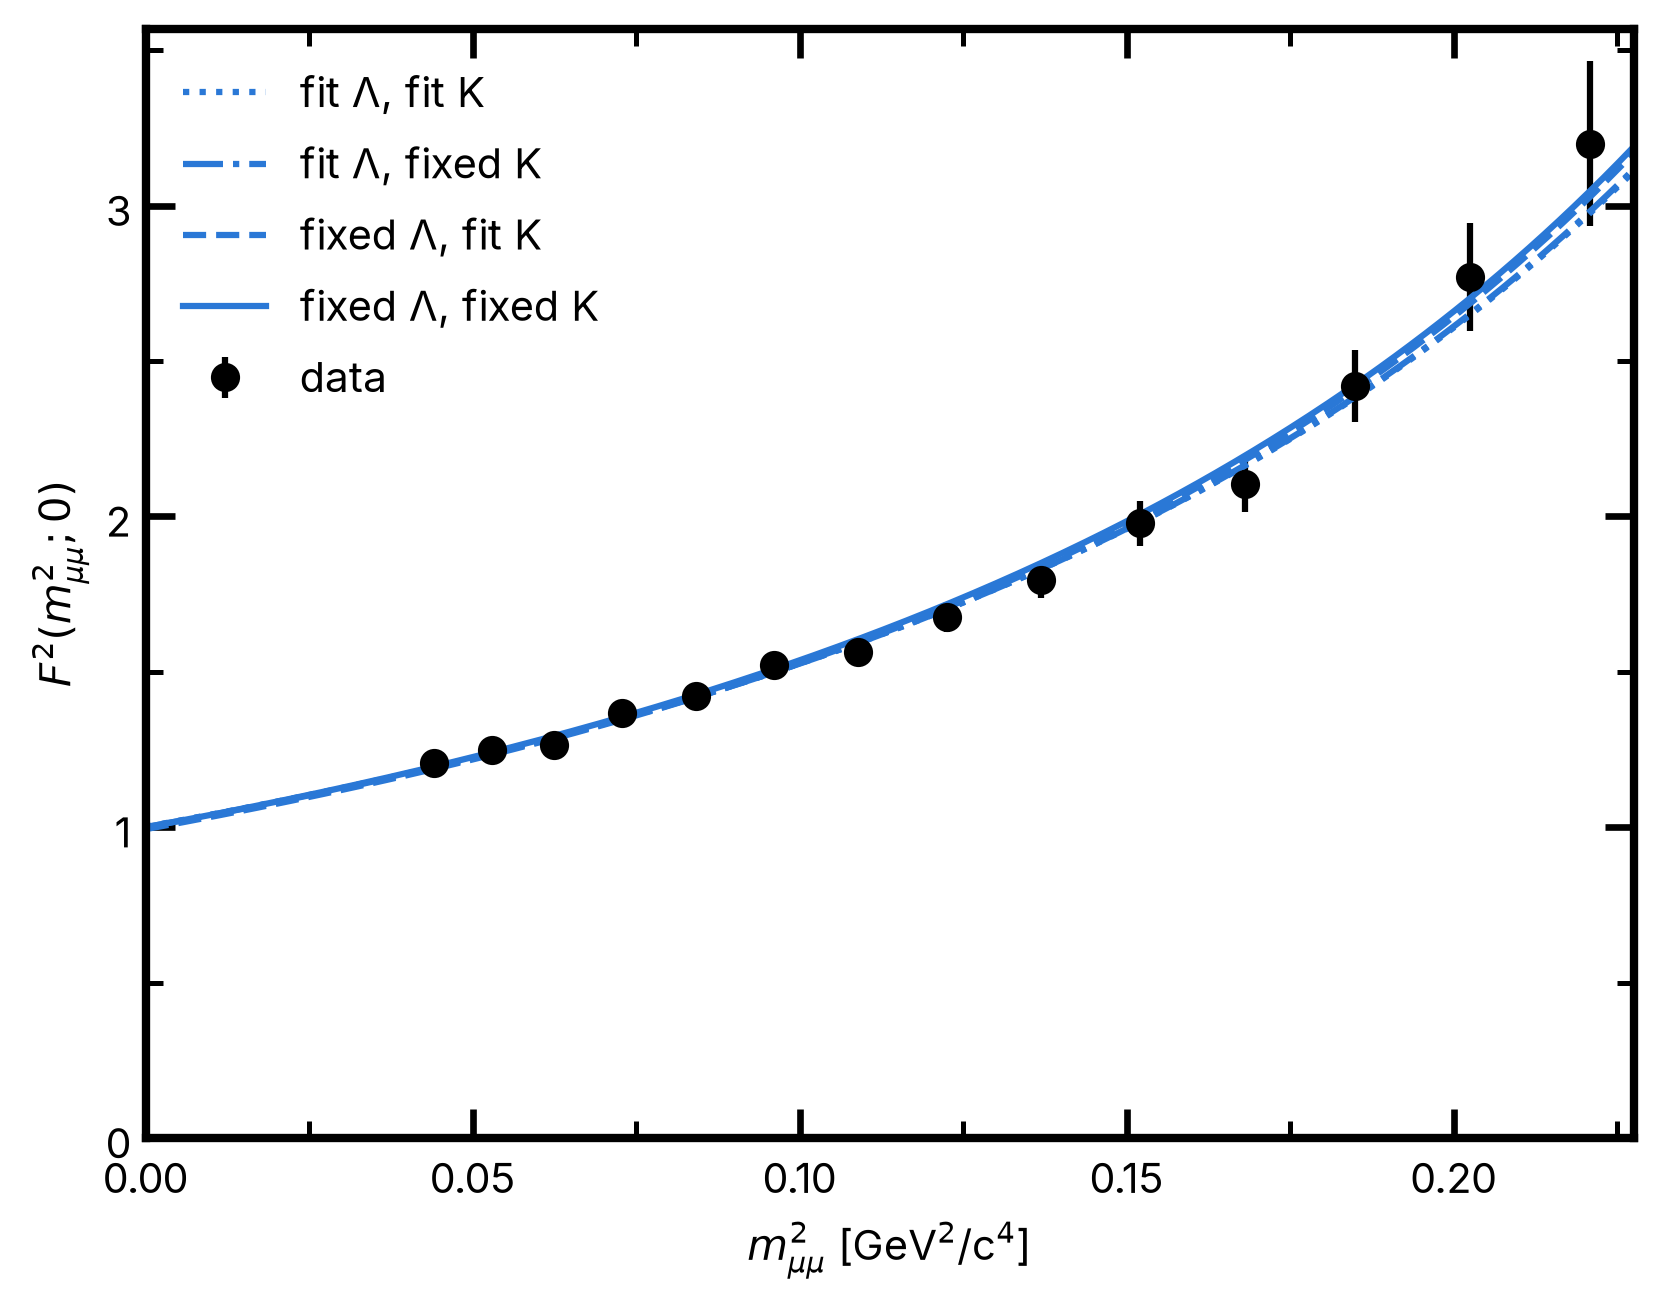

In [7]:
# Plot data with error bars and the fitted curve
plt.errorbar(x, y, yerr=yerr, fmt='o', color=COLORS['data'], label='data')

# Left edge pinned to 0 (physical q^2=0); a little padding added on the right
# only, so the rightmost data point/marker isn't clipped by the axis edge.
x_pad = 0.03 * x.max()
xx = np.linspace(0, x.max() + x_pad, 400)
curve0 = ff.F2(xx, fits[0]['Lambda'], fits[0]['K'])
curve1 = ff.F2(xx, fits[1]['Lambda'], fits[1]['K'])
curve2 = ff.F2(xx, fits[2]['Lambda'], fits[2]['K'])
curve3 = ff.F2(xx, fits[3]['Lambda'], fits[3]['K'])
plt.plot(xx, curve0, ':', color=COLORS['primary'], label="fit Λ, fit K")
plt.plot(xx, curve1, '-.', color=COLORS['primary'], label="fit Λ, fixed K")
plt.plot(xx, curve2, '--', color=COLORS['primary'], label="fixed Λ, fit K")
plt.plot(xx, curve3, '-', color=COLORS['primary'], label="fixed Λ, fixed K")
plt.legend(frameon=False)
plt.xlabel(r"$m^2_{\mu\mu}$ [GeV$^2$/c$^4$]")
plt.ylabel(r"$F^2(m^2_{\mu\mu}; 0)$")
# plt.title("form factor of eta meson")

y_max = max(np.max(y + yerr), curve0.max(), curve1.max(), curve2.max(), curve3.max())
y_pad = 0.03 * y_max
ax = plt.gca()
ax.set_xlim(0, x.max() + x_pad)
ax.set_ylim(0, y_max + y_pad)
style_axes(ax, n_minor=2, integer_y=True)
plt.show()


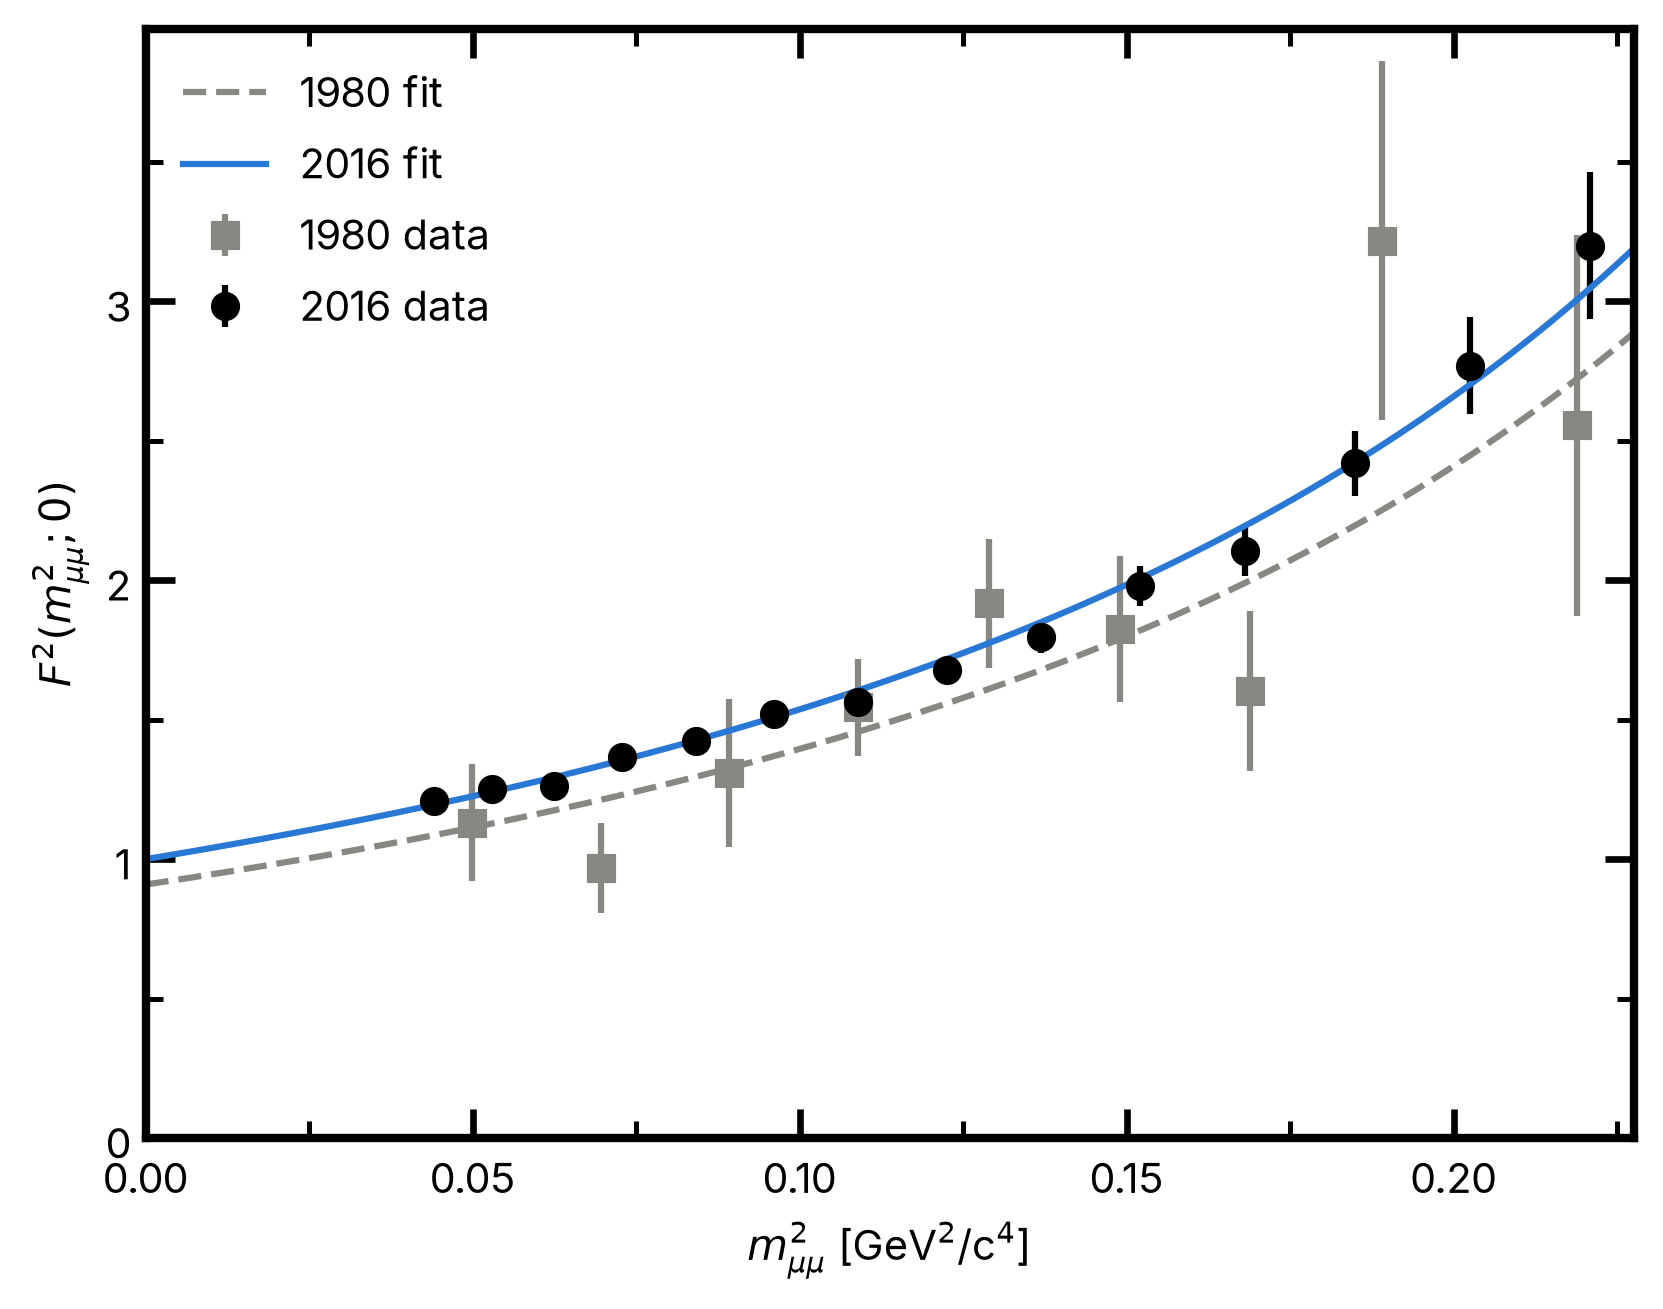

In [8]:
# Compare old 1980 paper data/fit against the new (1608.07898) data/fit
x_old = np.array([0.04994, 0.06962, 0.08918, 0.10887, 0.12889, 0.14895, 0.16888,
                    0.18911, 0.2188])  # mass^2, GeV^2/c^4
y_old = np.array([1.13117, 0.96908, 1.30802, 1.54427, 1.91811, 1.82588, 1.60247,
                    3.21721, 2.55531])
ybar_old = [1.34043, 1.13093, 1.57283, 1.71686, 2.14894, 2.08674, 1.89034, 3.86088,
             3.23895]  # upper error bars
yerr_old = np.subtract(ybar_old, y_old)
Lambda_old, K_old = 0.72, 0.9089376019880376  # from 1980 paper

# Left edge pinned to 0 (physical q^2=0); a little padding added on the right
# only, so the rightmost data point/marker isn't clipped by the axis edge.
x_max = max(x.max(), x_old.max())
x_pad = 0.03 * x_max
xx = np.linspace(0, x_max + x_pad, 400)
old_fit_curve = ff.F2(xx, Lambda_old, K_old)
# Use the fixed-Lambda, fixed-K entry from the 2x2 fit table (fits[3]) so the
# "2016 fit" shown here always matches the fixed/fixed result, not a re-fit.
new_fit_curve = ff.F2(xx, fits[3]['Lambda'], fits[3]['K'])

plt.errorbar(x_old, y_old, yerr=yerr_old, fmt='s', color=COLORS['reference'], label='1980 data')
plt.plot(xx, old_fit_curve, '--', color=COLORS['reference'], label='1980 fit')

plt.errorbar(x, y, yerr=yerr, fmt='o', color=COLORS['data'], label='2016 data')
plt.plot(xx, new_fit_curve, '-', color=COLORS['primary'], label='2016 fit')

plt.legend(frameon=False)
plt.xlabel(r"$m^2_{\mu\mu}$ [GeV$^2$/c$^4$]")
plt.ylabel(r"$F^2(m^2_{\mu\mu}; 0)$")
# plt.title("form factor of eta meson: 1980 vs 2016")

y_max = max(np.max(y + yerr), np.max(y_old + yerr_old), old_fit_curve.max(), new_fit_curve.max())
y_pad = 0.03 * y_max
ax = plt.gca()
ax.set_xlim(0, x_max + x_pad)
ax.set_ylim(0, y_max + y_pad)
style_axes(ax, n_minor=2, integer_y=True)
plt.show()


These fits are all in very close agreement, deviating most significantly at the tail end (which is expected given the greater variance and fewer data points).

## Uncertainty Propagation

### Method I: Numerical Propagation

Here, we sample `n` values of Λ normally distributed about its mean, with standard deviation $\sigma_\Lambda$.

For each Λ sampled, we compute the branching ratio. We then collect all these branching ratio values and find their mean and standard deviation.

In [9]:
ff = FormFactor()
n = 10000
Lambdas = np.random.normal(LAMBDA0[0], LAMBDA0[1], n)

br_values = []
for Lambda in Lambdas:
    int_val, int_err = ff.integrate(Lambda)
    br = ff.branching_ratio(Lambda)
    br_values.append(br)

br_values = np.array(br_values)
br_mean = np.mean(br_values)
br_unc  = math.sqrt(np.std(br_values)**2 + int_err**2)
print(f"BR = ({br_mean * 10000.:.2f} ± {br_unc * 10000.:.2f})e-4")

BR = (3.25 ± 0.07)e-4


The result is in agreement with previous calculations (somewhat too high).

---

### Method II: $\pm\sigma$ Difference
Calculate branching ratio from $\Lambda+\sigma_\Lambda$ and $\Lambda-\sigma_\Lambda$, find the difference, then divide by 2. This method is quick and works well if the lambda uncertainty is smooth and approximately linear.

In [10]:
# Define Lambda values
Lambda_p = LAMBDA0[0] + LAMBDA0[1]
Lambda_m = LAMBDA0[0] - LAMBDA0[1]

ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)

br_p = ff_p.branching_ratio(Lambda_p)
br_m = ff_m.branching_ratio(Lambda_m)

# Print values
print(f"BR+ = {br_p * 10000.:.2f}e-4")
print(f"BR- = {br_m * 10000.:.2f}e-4\n")

# Find difference
br_unc = abs((br_p - br_m)) / 2.
print(f"BR uncertainty = {br_unc * 10000.:.2f}e-4\n")

BR+ = 3.18e-4
BR- = 3.31e-4

BR uncertainty = 0.07e-4



Phil also mentioned a slightly different method of doing this. I'll try it just to see if there's any difference.

In [11]:
# Define Lambda values
Lambda_p = LAMBDA0[0] + LAMBDA0[1]
Lambda_m = LAMBDA0[0] - LAMBDA0[1]

ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)
ff = FormFactor(Lambda0=LAMBDA0[0])

br_unc_p = ff_p.branching_ratio(Lambda_p) - ff.branching_ratio(LAMBDA0[0])
br_unc_m = ff.branching_ratio(LAMBDA0[0]) - ff_m.branching_ratio(Lambda_m)

# Print values
print(f"ΔBR+ = {br_unc_p * 10000.:.2f}e-4")
print(f"ΔBR- = {br_unc_m * 10000.:.2f}e-4\n")

# Find average
br_unc = abs((br_unc_p + br_unc_m)) / 2.
print(f"BR uncertainty = {br_unc * 10000.:.2f}e-4\n")

ΔBR+ = -0.06e-4
ΔBR- = -0.07e-4

BR uncertainty = 0.07e-4



The end result is the same.

### Plot of (br uncertainty / br) vs q2 max

Optimal q2_max = 0.1122 GeV^2/c^4
  syst (Lambda) = 1.480%, stat (yield) = 1.650%, total = 2.216%
  retained signal ~ 160,166 of 223,295 (71.7%)
  BR = 2.326e-4, total unc = 0.052e-4
|   q2_max | syst (Lambda)   | stat (yield)   | total   |   N_retained |
|----------|-----------------|----------------|---------|--------------|
|   0.0455 | 0.828%          | 23.326%        | 23.341% |          801 |
|   0.0626 | 1.021%          | 2.939%         | 3.111%  |       50,485 |
|   0.0797 | 1.194%          | 2.102%         | 2.418%  |       98,649 |
|   0.0968 | 1.351%          | 1.794%         | 2.246%  |      135,389 |
|   0.1139 | 1.494%          | 1.638%         | 2.217%  |      162,513 |
|   0.131  | 1.622%          | 1.546%         | 2.241%  |      182,277 |
|   0.1481 | 1.735%          | 1.490%         | 2.287%  |      196,480 |
|   0.1651 | 1.833%          | 1.453%         | 2.339%  |      206,488 |
|   0.1822 | 1.915%          | 1.429%         | 2.390%  |      213,337 |
|   0.1993 | 1

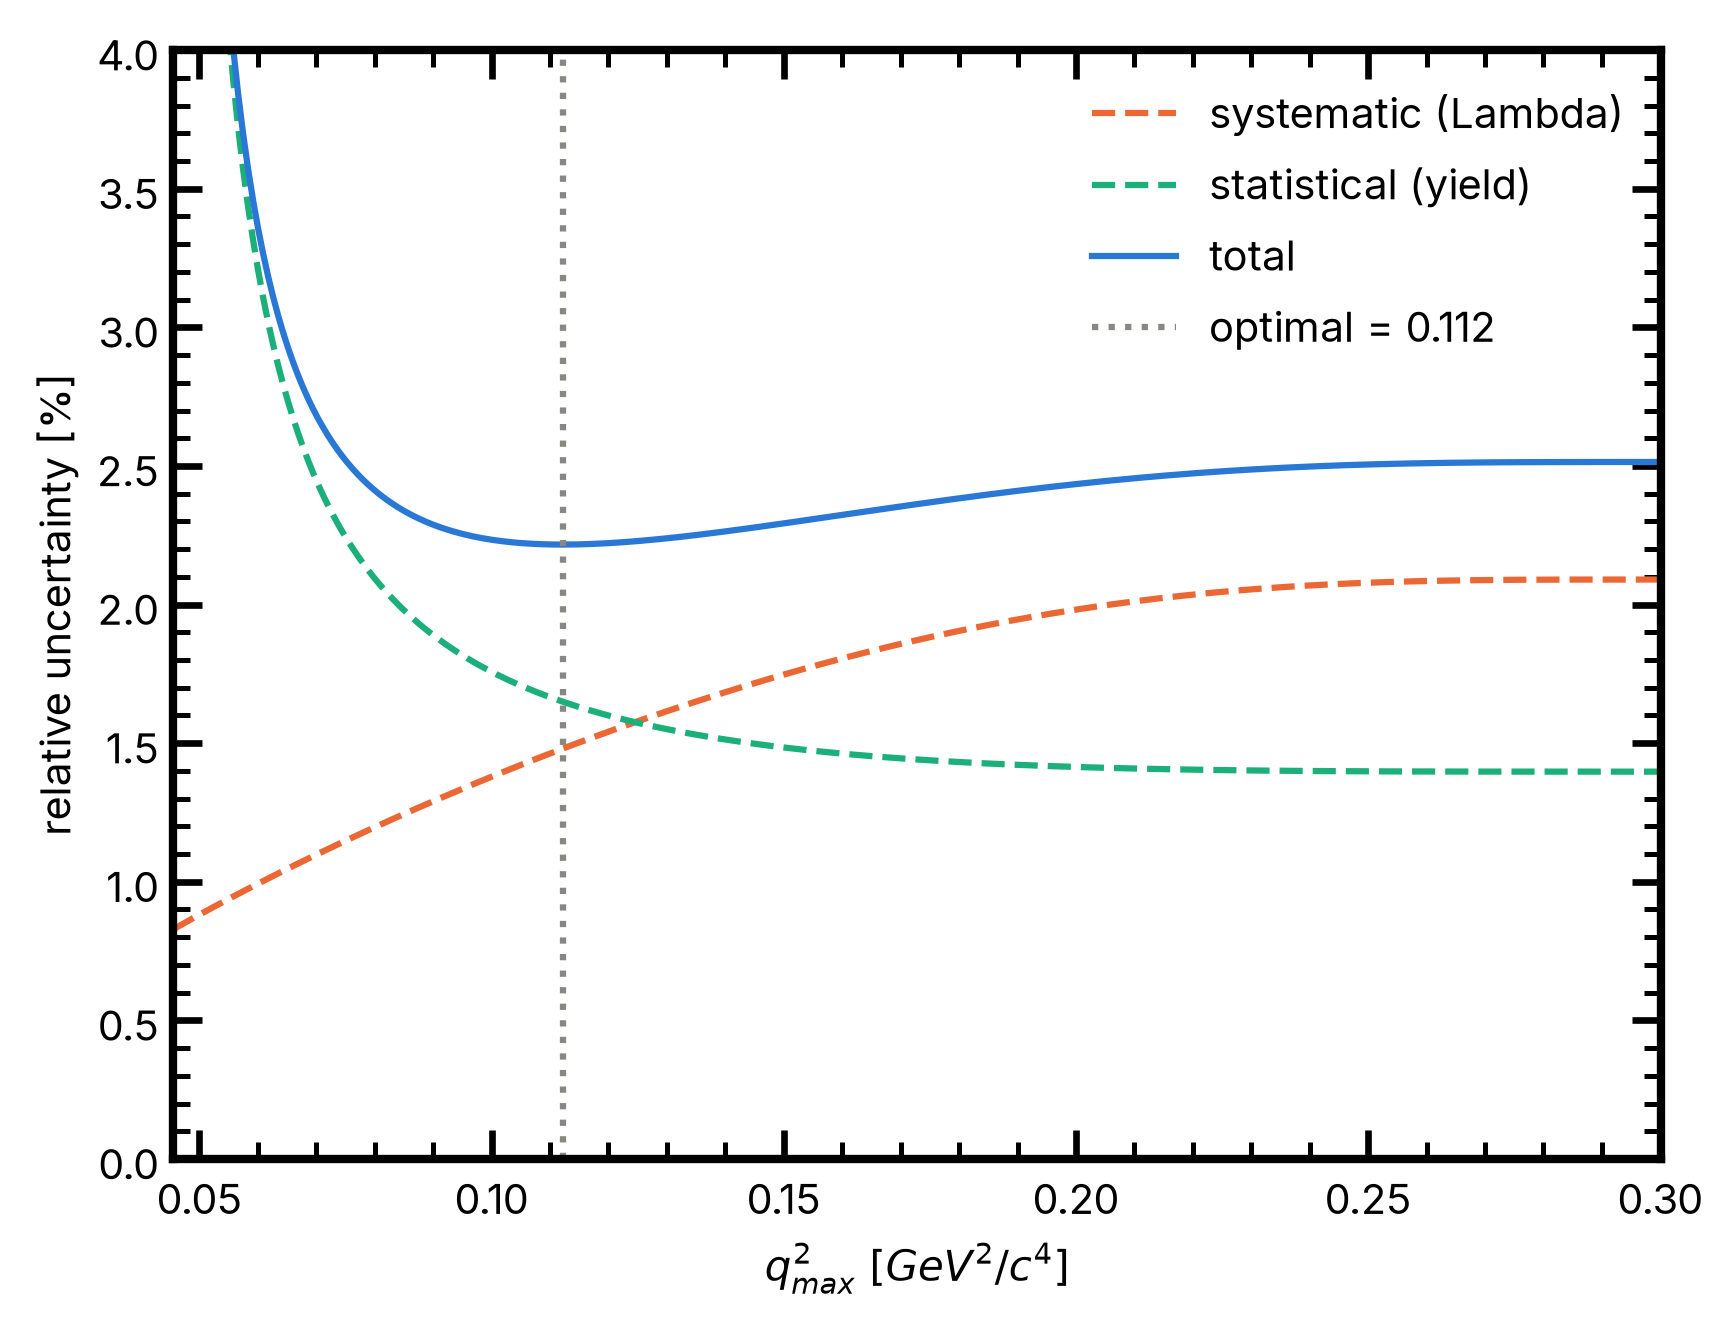

In [12]:
# eta -> mu+ mu- gamma signal yield (full q2 range), from a mass fit to
# 2018 Turbo data (Collision 18, Run 2, leptons stream).
N_SIG, DN_SIG = 223295, 3120  # signal candidates, full kinematic range

# BR0, DBR0 defined in the constants cell above.

# m_eta and alpha are known physical constants (set in the constants cell above) --
# no need to guess or back-solve for them like the old 1980-reconstruction did.
ff = FormFactor()

# Define Lambda values
Lambda0, dLambda0 = LAMBDA0
Lambda_p = Lambda0 + dLambda0
Lambda_m = Lambda0 - dLambda0

# Scan q2_max across the full physical kinematic range [q2_min, m_eta^2]
q2_max_values = np.linspace(ff.q2_min, ff.q2_max, 300)[1:]  # skip q2_min itself (br=0 there)

br_full, _ = ff.integrate(Lambda0)
br_full *= ff.prefactor

values = []  # [q2_max, syst_rel, stat_rel, total_rel, br, dbr, n_retained]
for q2_max in q2_max_values:
    bounds = [ff.q2_min, q2_max]

    I_o, _ = ff.integrate(Lambda0, bounds=bounds)
    I_p, _ = ff.integrate(Lambda_p, bounds=bounds)
    I_m, _ = ff.integrate(Lambda_m, bounds=bounds)

    br = ff.prefactor * I_o
    dbr = ff.prefactor * np.abs(I_p - I_m) / 2.0
    syst_rel = dbr / br if np.isfinite(br) and br != 0.0 else np.nan

    # Retained fraction of the full-range branching ratio -> retained signal
    # candidates -> statistical uncertainty. This assumes the fitted yield
    # scales with the retained q2 range the same way the branching ratio does
    # (i.e. background dilutes proportionally); a real per-bin yield fit would
    # be more precise than this global rescaling.
    frac = br / br_full
    n_retained = N_SIG * frac
    stat_rel = (DN_SIG / N_SIG) / np.sqrt(frac) if frac > 0 else np.nan

    total_rel = np.sqrt(syst_rel**2 + stat_rel**2)
    values.append([q2_max, syst_rel, stat_rel, total_rel, br, dbr, n_retained])

values = np.array(values)

best_idx = np.nanargmin(values[:, 3])
best_q2max, best_syst, best_stat, best_total, best_br, best_dbr, best_n = values[best_idx]
print(f"Optimal q2_max = {best_q2max:.4f} GeV^2/c^4")
print(f"  syst (Lambda) = {best_syst:.3%}, stat (yield) = {best_stat:.3%}, total = {best_total:.3%}")
print(f"  retained signal ~ {best_n:,.0f} of {N_SIG:,} ({best_n/N_SIG:.1%})")
print(f"  BR = {best_br*1e4:.3f}e-4, total unc = {best_total*best_br*1e4:.3f}e-4")

# Table across a coarser grid, for reference
rows = list(values[::20])
if not np.array_equal(rows[-1], values[-1]):
    rows.append(values[-1])
table = [[f"{q2:.4f}", f"{s:.3%}", f"{st:.3%}", f"{t:.3%}", f"{n:,.0f}"] for q2, s, st, t, br, dbr, n in rows]
print(tabulate(table, headers=['q2_max', 'syst (Lambda)', 'stat (yield)', 'total', 'N_retained'], tablefmt="github"))

# Plot: systematic, statistical, and total relative uncertainty vs q2_max.
plt.plot(values[:, 0], values[:, 1] * 100, '--', color=COLORS['tertiary'], label='systematic (Lambda)')
plt.plot(values[:, 0], values[:, 2] * 100, '--', color=COLORS['secondary'], label='statistical (yield)')
plt.plot(values[:, 0], values[:, 3] * 100, '-', color=COLORS['primary'], label='total')
plt.axvline(best_q2max, color=COLORS['reference'], linestyle=':', label=f'optimal = {best_q2max:.3f}')
plt.xlabel(r'$q^2_{max}\,\, [GeV^2/c^4]$')
plt.ylabel('relative uncertainty [%]')
# plt.title(r'BR relative uncertainty vs $q^2_{max}$')
ax = plt.gca()
ax.margins(x=0)
ax.set_ylim(0, 4)
# plt.grid()
plt.legend(frameon=False)
style_axes(ax)
plt.show()
